## Normal Scaled

In [19]:
using Distributions, Random, Statistics, MultipleTesting, Empirikos, Hypatia, LinearAlgebra
using Distributions, StatsPlots, Random

Random.seed!(105)
n_values = [4, 5, 6, 8, 10, 20, 30, 40]
G = 1000
R = 100
p_signal = 0.1
β_signal = 4.0

# parametric variance model
s0_sq_true = 1.0
d0_true    = 4.0

datasets = Dict{Tuple{Int,Int}, Any}()

for n in n_values
    for r in 1:R
        rng = MersenneTwister(10_000 + 100n + r)

        is_DE = rand(rng, G) .< p_signal

        # sigma^2 from the correct parametric prior
        σ2 = rand(rng, InverseGamma(d0_true / 2, d0_true * s0_sq_true / 2), G)
        σ  = sqrt.(σ2)

        # data generation
        Y = [
            rand(rng, Normal(is_DE[i] ? β_signal * σ[i]/ sqrt(n) : 0.0, σ[i]), n)
            for i in 1:G
        ]

        datasets[(n, r)] = (
            Y = Y,
            is_DE = is_DE,
            σ = σ,
            σ2 = σ2
        )
    end
end

In [18]:
datasets

Dict{Tuple{Int64, Int64}, Any} with 800 entries:
  (10, 79) => (Y = [[2.83205, 0.315565, -1.8768, -0.316528, 1.1283, 1.32902, 2.…
  (30, 68) => (Y = [[0.0165074, 0.0571174, 0.459991, -0.424326, 0.749755, 1.050…
  (40, 28) => (Y = [[-0.313257, -1.08093, -0.529138, -0.430393, -0.616867, -0.9…
  (10, 17) => (Y = [[-0.856933, -1.63848, -0.163199, 0.833631, -0.354057, -0.44…
  (30, 41) => (Y = [[0.528572, -0.482191, -1.62712, 1.67789, -0.123802, 3.12464…
  (40, 65) => (Y = [[0.0815584, -0.154493, -1.03143, 0.359565, -1.2862, -0.4722…
  (20, 26) => (Y = [[2.18778, 1.88097, -0.65084, 1.33329, 1.16489, -0.0135252, …
  (30, 23) => (Y = [[1.22417, 1.38679, -0.728215, -1.73403, -0.952736, 2.51345,…
  (8, 91)  => (Y = [[0.401725, 0.433981, -0.0790698, -1.1257, 0.478835, 0.92107…
  (10, 59) => (Y = [[0.459849, 0.851058, -0.500595, 0.131807, 0.14367, -0.14342…
  (6, 29)  => (Y = [[2.05688, 1.0874, -0.189153, -0.522503, 1.11596, 1.25187], …
  (6, 75)  => (Y = [[0.477434, -0.174208, 0.679352, 0.965212

In [5]:
limma_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[],
    "TP_top100" => Float64[]
)

# Store full per-gene p-values
limma_pvals_store = Dict{Tuple{Int,Int}, Vector{Float64}}()

# Store replicate-level top-100 results
limma_top100_store = Dict{Tuple{Int,Int}, Int}()


# =========================================================
# Loop over sample sizes
# =========================================================
for n in n_values

    println("\n========== Running LIMMA simulation for n = $n ==========")

    ν = n - 1

    power_vals  = Float64[]
    fdr_vals    = Float64[]
    tp_vals     = Float64[]
    fp_vals     = Float64[]
    top100_vals = Float64[]

    for r in 1:R

        try
            Y     = datasets[(n,r)].Y
            is_DE = datasets[(n,r)].is_DE
            σ     = datasets[(n,r)].σ

            # -------------------------------------------------
            # Per-gene statistics
            # -------------------------------------------------
            β_hat = [mean(Y[i]) for i in 1:G]

            s_hat = [
                std(Y[i], corrected=true)
                for i in 1:G
            ]

            se_hat_squared = (s_hat .^ 2) ./ n


            # -------------------------------------------------
            # LIMMA samples
            # -------------------------------------------------
            samples = [
                Empirikos.NormalChiSquareSample(
                    β_hat[i],
                    se_hat_squared[i],
                    ν
                )
                for i in 1:G
            ]


            # -------------------------------------------------
            # Fit LIMMA EB test
            # -------------------------------------------------
            test_limma = Empirikos.EmpiricalPartiallyBayesTTest(
                α = 0.05,
                prior = Empirikos.Limma(),
                solver = Hypatia.Optimizer
            )

            res_limma = fit(test_limma, samples)


            # -------------------------------------------------
            # Extract p-values and rejection decisions
            # -------------------------------------------------
            pvals_limma = res_limma.pvalue
            rej_limma   = res_limma.rj_idx


            # =================================================
            # SAVE THE RAW P-VALUES
            # =================================================
            limma_pvals_store[(n,r)] = copy(pvals_limma)


            # =================================================
            # Standard rejection-based metrics
            # =================================================
            TP = sum(rej_limma .& is_DE)
            FP = sum(rej_limma .& .!is_DE)

            power = TP / max(sum(is_DE), 1)

            fdr = FP / max(sum(rej_limma), 1)


            # =================================================
            # Ranking metric: true signals among top 100
            # =================================================
            k = min(100, G)

            ord = sortperm(pvals_limma)

            top_idx = ord[1:k]

            TP_top100 = sum(is_DE[top_idx])


            # Store replicate-level ranking result
            limma_top100_store[(n,r)] = TP_top100


            # -------------------------------------------------
            # Collect replicate metrics
            # -------------------------------------------------
            push!(tp_vals, TP)
            push!(fp_vals, FP)

            push!(power_vals, power)
            push!(fdr_vals, fdr)

            push!(top100_vals, TP_top100)


        catch err

            @warn "Skipping Rep $r for n=$n due to numerical error: $err"

            continue
        end
    end


    # =========================================================
    # Average over replicates
    # =========================================================
    mean_TP     = mean(tp_vals)
    mean_FP     = mean(fp_vals)

    mean_power  = mean(power_vals)
    mean_fdr    = mean(fdr_vals)

    mean_top100 = mean(top100_vals)


    push!(limma_summary["n"], n)

    push!(limma_summary["TP"], mean_TP)
    push!(limma_summary["FP"], mean_FP)

    push!(limma_summary["Power"], mean_power)
    push!(limma_summary["FDR"], mean_fdr)

    push!(limma_summary["TP_top100"], mean_top100)


    println(
        "n = $n → " *
        "Power=$(round(mean_power, digits=3)) | " *
        "FDR=$(round(mean_fdr, digits=3)) | " *
        "TP=$(round(mean_TP, digits=1)) | " *
        "FP=$(round(mean_FP, digits=1)) | " *
        "TP@100=$(round(mean_top100, digits=1))"
    )
end


# =========================================================
# Final summary
# =========================================================
println("\n========== LIMMA SUMMARY ACROSS SAMPLE SIZES ==========")

for i in eachindex(limma_summary["n"])

    println(
        "n = $(limma_summary["n"][i]) → " *
        "Power=$(round(limma_summary["Power"][i], digits=5)), " *
        "FDR=$(round(limma_summary["FDR"][i], digits=5)), " *
        "TP@100=$(round(limma_summary["TP_top100"][i], digits=3))"
    )
end


========== Running LIMMA simulation for n = 4 ==========
n = 4 → Power=0.346 | FDR=0.042 | TP=34.7 | FP=1.7 | TP@100=80.6

========== Running LIMMA simulation for n = 5 ==========
n = 5 → Power=0.435 | FDR=0.049 | TP=43.8 | FP=2.3 | TP@100=82.3

========== Running LIMMA simulation for n = 6 ==========
n = 6 → Power=0.505 | FDR=0.052 | TP=50.6 | FP=2.8 | TP@100=82.9

========== Running LIMMA simulation for n = 8 ==========
n = 8 → Power=0.598 | FDR=0.043 | TP=60.0 | FP=2.8 | TP@100=84.8

========== Running LIMMA simulation for n = 10 ==========
n = 10 → Power=0.665 | FDR=0.044 | TP=66.9 | FP=3.2 | TP@100=85.9

========== Running LIMMA simulation for n = 20 ==========
n = 20 → Power=0.765 | FDR=0.045 | TP=76.8 | FP=3.7 | TP@100=87.8

========== Running LIMMA simulation for n = 30 ==========
n = 30 → Power=0.812 | FDR=0.045 | TP=80.0 | FP=3.9 | TP@100=88.5

========== Running LIMMA simulation for n = 40 ==========
n = 40 → Power=0.83 | FDR=0.046 | TP=82.8 | FP=4.0 | TP@100=89.2

========

## NP +SD

In [6]:
R = 100

# =========================================================
# Storage for summary results
# =========================================================
epb_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[],
    "TP_top100" => Float64[]
)

# Store full raw p-values for every successful replicate
epb_pvals_store = Dict{Tuple{Int,Int}, Vector{Float64}}()

# Store replicate-level TP@100
epb_top100_store = Dict{Tuple{Int,Int}, Int}()


# =========================================================
# Loop over sample sizes
# =========================================================
for n in n_values

    println("\n========== Running EPB NPMLE simulation for n = $n ==========")

    ν = n - 1

    power_vals  = Float64[]
    fdr_vals    = Float64[]
    tp_vals     = Float64[]
    fp_vals     = Float64[]
    top100_vals = Float64[]

    for r in 1:R

        try
            # -------------------------------------------------
            # Get the same simulated dataset
            # -------------------------------------------------
            Y     = datasets[(n,r)].Y
            is_DE = datasets[(n,r)].is_DE
            σ     = datasets[(n,r)].σ


            # -------------------------------------------------
            # Compute per-gene statistics
            # -------------------------------------------------
            β_hat = [mean(Y[i]) for i in 1:G]

            s_hat = [
                std(Y[i], corrected=true)
                for i in 1:G
            ]

            se_hat_squared = (s_hat .^ 2) ./ n


            # -------------------------------------------------
            # Build Normal-Chi-square samples
            # -------------------------------------------------
            samples = [
                Empirikos.NormalChiSquareSample(
                    β_hat[i],
                    se_hat_squared[i],
                    ν
                )
                for i in 1:G
            ]


            # -------------------------------------------------
            # Fit EPB with nonparametric NPMLE prior
            # -------------------------------------------------
            test_epb = Empirikos.EmpiricalPartiallyBayesTTest(
                α = 0.05,
                solver = Hypatia.Optimizer
            )

            res_epb = fit(test_epb, samples)


            # -------------------------------------------------
            # Extract p-values and rejection decisions
            # -------------------------------------------------
            pvals_epb = res_epb.pvalue
            rej_epb   = res_epb.rj_idx


            # =================================================
            # SAVE RAW P-VALUES
            # =================================================
            epb_pvals_store[(n,r)] = copy(pvals_epb)


            # =================================================
            # Standard rejection-based metrics
            # =================================================
            TP = sum(rej_epb .& is_DE)
            FP = sum(rej_epb .& .!is_DE)

            power = TP / max(sum(is_DE), 1)

            fdr = FP / max(sum(rej_epb), 1)


            # =================================================
            # Ranking metric: true DE genes among top 100
            # =================================================
            k = min(100, G)

            ord = sortperm(pvals_epb)

            top_idx = ord[1:k]

            TP_top100 = sum(is_DE[top_idx])


            # Store replicate-level TP@100
            epb_top100_store[(n,r)] = TP_top100


            # -------------------------------------------------
            # Collect replicate metrics
            # -------------------------------------------------
            push!(tp_vals, TP)
            push!(fp_vals, FP)

            push!(power_vals, power)
            push!(fdr_vals, fdr)

            push!(top100_vals, TP_top100)


            println(
                "Rep $r → " *
                "Power=$(round(power, digits=3)) | " *
                "FDR=$(round(fdr, digits=3)) | " *
                "Rej=$(sum(rej_epb)) | " *
                "TP@100=$TP_top100"
            )


        catch e

            @warn "Skipping Rep $r for n=$n due to error: $e"

            continue
        end
    end


    # =========================================================
    # Average over successful replicates
    # =========================================================
    mean_TP     = mean(tp_vals)
    mean_FP     = mean(fp_vals)

    mean_power  = mean(power_vals)
    mean_fdr    = mean(fdr_vals)

    mean_top100 = mean(top100_vals)


    push!(epb_summary["n"], n)

    push!(epb_summary["TP"], mean_TP)
    push!(epb_summary["FP"], mean_FP)

    push!(epb_summary["Power"], mean_power)
    push!(epb_summary["FDR"], mean_fdr)

    push!(epb_summary["TP_top100"], mean_top100)


    println(
        "n = $n → " *
        "Power=$(round(mean_power, digits=3)) | " *
        "FDR=$(round(mean_fdr, digits=3)) | " *
        "TP=$(round(mean_TP, digits=1)) | " *
        "FP=$(round(mean_FP, digits=1)) | " *
        "TP@100=$(round(mean_top100, digits=1))"
    )
end


# =========================================================
# Final summary
# =========================================================
println("\n========== EPB SUMMARY ACROSS SAMPLE SIZES ==========")

for i in eachindex(epb_summary["n"])

    println(
        "n = $(epb_summary["n"][i]) → " *
        "TP=$(round(epb_summary["TP"][i], digits=3)), " *
        "FP=$(round(epb_summary["FP"][i], digits=3)), " *
        "Power=$(round(epb_summary["Power"][i], digits=5)), " *
        "FDR=$(round(epb_summary["FDR"][i], digits=5)), " *
        "TP@100=$(round(epb_summary["TP_top100"][i], digits=3))"
    )
end


========== Running EPB NPMLE simulation for n = 4 ==========

 iter        p_obj        d_obj |  abs_gap    x_feas    z_feas |      tau       kap        mu | dir_res     prox  step     alpha
    0   3.2373e-02  -2.6562e+02 | 2.30e+03  1.74e+02  3.17e+00 | 1.00e+00  1.00e+00  1.00e+00 |
    1  -5.6432e-01  -2.7008e+02 | 2.19e+03  1.77e+02  3.21e+00 | 9.36e-01  1.02e+00  9.50e-01 | 3.3e-12  8.9e-02  co-a  5.00e-02
    2  -1.4129e+00  -2.7243e+02 | 2.08e+03  1.78e+02  3.23e+00 | 8.84e-01  1.02e+00  9.03e-01 | 7.4e-13  1.5e-01  co-a  5.00e-02
    3  -3.9967e+00  -2.7572e+02 | 1.87e+03  1.78e+02  3.24e+00 | 7.93e-01  1.02e+00  8.12e-01 | 2.1e-12  4.4e-01  co-a  1.00e-01
    4  -8.4025e+00  -2.8102e+02 | 1.68e+03  1.79e+02  3.25e+00 | 7.11e-01  1.03e+00  7.31e-01 | 3.7e-13  9.3e-02  co-a  1.00e-01
    5  -1.4877e+01  -2.8759e+02 | 1.51e+03  1.79e+02  3.26e+00 | 6.40e-01  1.03e+00  6.58e-01 | 1.5e-12  3.2e-02  co-a  1.00e-01
    6  -2.4142e+01  -2.9678e+02 | 1.36e+03  1.79e+02  3.26e+00 | 5.

Excessive output truncated after 524326 bytes.

   61  -1.1363e+01  -1.1725e+01 | 9.57e-01  1.65e-01  2.87e-03 

In [7]:

# =========================================================
# Final summary
# =========================================================
println("\n========== EPB SUMMARY ACROSS SAMPLE SIZES ==========")

for i in eachindex(epb_summary["n"])

    println(
        "n = $(epb_summary["n"][i]) → " *
        "TP=$(round(epb_summary["TP"][i], digits=3)), " *
        "FP=$(round(epb_summary["FP"][i], digits=3)), " *
        "Power=$(round(epb_summary["Power"][i], digits=5)), " *
        "FDR=$(round(epb_summary["FDR"][i], digits=5)), " *
        "TP@100=$(round(epb_summary["TP_top100"][i], digits=3))"
    )
end


========== EPB SUMMARY ACROSS SAMPLE SIZES ==========
n = 4 → TP=35.556, FP=1.869, Power=0.35516, FDR=0.04589, TP@100=80.424
n = 5 → TP=45.01, FP=2.49, Power=0.44744, FDR=0.05073, TP@100=82.25
n = 6 → TP=50.99, FP=3.051, Power=0.50943, FDR=0.05549, TP@100=82.848
n = 8 → TP=60.48, FP=2.89, Power=0.60328, FDR=0.04386, TP@100=84.61
n = 10 → TP=67.14, FP=3.26, Power=0.66697, FDR=0.0453, TP@100=85.87
n = 20 → TP=77.03, FP=3.68, Power=0.76835, FDR=0.04462, TP@100=87.84
n = 30 → TP=80.222, FP=3.909, Power=0.81396, FDR=0.04547, TP@100=88.444
n = 40 → TP=82.67, FP=4.13, Power=0.82891, FDR=0.04685, TP@100=89.15


## MAD P

In [11]:
using FastGaussQuadrature
using Distributions
using StatsFuns: logsumexp
using Optim
using MultipleTesting
using Statistics, Random, LinearAlgebra
using ApproxFun, SpecialFunctions

# =========================================================
# 1. Exact MAD-about-mean likelihood
# =========================================================

struct MADDistribution{T<:Real,S<:Integer} <: ContinuousUnivariateDistribution
    σ::T
    n::S
end

import Distributions: pdf, logpdf, insupport, minimum, maximum

function G_recursive(max_r::Int; a=0.0, b=100)
    d = Interval(a, b)
    G = Vector{Fun}(undef, max_r+1)
    G[1] = Fun(x -> 1.0, d)
    for r in 1:max_r
        integrand = Fun(x -> exp(-(x^2)/(2r*(r+1))), d) * G[r]
        G[r+1] = cumsum(integrand)
    end
    return G
end

const _Gcache = Dict{Int,Vector{Fun}}()
_getG(n) = get!(_Gcache, n) do
    G_recursive(n)
end

function _pdf_sigma1(n::Int, m::Real)
    m < 0 && return zero(float(m))
    z   = n * m / 2
    cst = n^(3/2) / (2^((n+1)/2) * π^((n-1)/2))
    G   = _getG(n)
    s   = 0.0
    @inbounds for k in 1:(n-1)
        s += binomial(n, k) * exp(-(m^2 * n^3) / (8k*(n-k))) * G[k](z) * G[n-k](z)
    end
    return cst * s
end

insupport(::MADDistribution, x::Real) = x ≥ 0
minimum(::MADDistribution) = 0.0
maximum(::MADDistribution) = Inf

pdf(d::MADDistribution, m::Real) =
    m < 0 ? 0.0 : (1 / d.σ) * _pdf_sigma1(d.n, m / d.σ)

function logpdf(d::MADDistribution, m::Real)
    m < 0 && return -Inf
    σ, n = d.σ, d.n
    z    = n * m / (2σ)
    logC = (3/2)*log(n) - ((n+1)/2)*log(2) - ((n-1)/2)*log(π)
    G    = _getG(n)

    logs = Float64[]
    @inbounds for k in 1:(n-1)
        val1 = G[k](z)
        val2 = G[n-k](z)
        if val1 > 0 && val2 > 0
            push!(logs,
                log(binomial(n, k)) -
                (m^2 * n^3) / (8σ^2 * k*(n-k)) +
                log(val1) + log(val2)
            )
        end
    end

    return -log(σ) + logC + (isempty(logs) ? -Inf : logsumexp(logs))
end

# =========================================================
# 2. Parametric prior on sigma^2
# =========================================================

struct InverseScaledChiSquare{T,S} <: ContinuousUnivariateDistribution
    σ²::T
    ν::S
end

function Distributions.InverseGamma(d::InverseScaledChiSquare)
    InverseGamma(d.ν / 2, d.ν * d.σ² / 2)
end

Distributions.pdf(d::InverseScaledChiSquare, x::Real) = pdf(InverseGamma(d), x)
Distributions.logpdf(d::InverseScaledChiSquare, x::Real) = logpdf(InverseGamma(d), x)

prior_sigma2(σ0², ν0) = InverseScaledChiSquare(σ0², ν0)

# =========================================================
# 3. Gauss-Legendre quadrature on (0,1)
# =========================================================

function gausslegendre01(K::Int)
    x, w = gausslegendre(K)   # nodes/weights on [-1,1]
    u = (x .+ 1) ./ 2         # map to (0,1)
    w = w ./ 2
    return u, w
end

# =========================================================
# 4. Marginal likelihood by Gauss-Legendre quadrature
#    transform s2 = u/(1-u), u in (0,1)
# =========================================================
function marginal_mad_logdensity_gl(
    D::Float64,
    n::Int,
    σ0²::Float64,
    ν0::Float64,
    u_nodes::Vector{Float64},
    u_weights::Vector{Float64}
)
    prior = prior_sigma2(σ0², ν0)

    logvals = similar(u_nodes)
    @inbounds for j in eachindex(u_nodes)
        u = clamp(u_nodes[j], 1e-12, 1 - 1e-12)
        s2 = u / (1 - u)
        jac = 1 / (1 - u)^2

        logvals[j] =
            logpdf(MADDistribution(sqrt(s2), n), D) +
            logpdf(prior, s2) +
            log(jac) +
            log(u_weights[j])
    end

    return logsumexp(logvals)
end

# =========================================================
# 5. Negative log marginal likelihood across genes
# =========================================================

function negloglik_mad_parametric_gl(
    par::Vector{Float64},
    mad_obs::Vector{Float64},
    n::Int,
    u_nodes::Vector{Float64},
    u_weights::Vector{Float64}
)
    η, ξ = par
    σ0² = exp(η)
    ν0  = exp(ξ)

    total = 0.0
    @inbounds for D in mad_obs
        total -= marginal_mad_logdensity_gl(D, n, σ0², ν0, u_nodes, u_weights)
    end
    return total
end

# =========================================================
# 6. Fit prior hyperparameters by Gaussian quadrature
# =========================================================

function fit_mad_parametric_prior_gl(
    mad_obs::Vector{Float64},
    n::Int;
    K_quad::Int = 64,
    init_logσ0² = log(max(median(mad_obs)^2, 1e-6)),
    init_logν0  = log(10.0),
    max_iter::Int = 80
)
    u_nodes, u_weights = gausslegendre01(K_quad)

    obj(par) = negloglik_mad_parametric_gl(par, mad_obs, n, u_nodes, u_weights)

    res = optimize(
        obj,
        [init_logσ0², init_logν0],
        NelderMead(),
        Optim.Options(iterations=max_iter, show_trace=false)
    )

    ηhat, ξhat = Optim.minimizer(res)

    return (
        σ0² = exp(ηhat),
        ν0  = exp(ξhat),
        optim = res,
        u_nodes = u_nodes,
        u_weights = u_weights
    )
end

# =========================================================
# 7. Posterior weights on same quadrature nodes
# =========================================================

function posterior_sigma2_weights_mad_gl(
    D::Float64,
    n::Int,
    σ0²::Float64,
    ν0::Float64,
    u_nodes::Vector{Float64},
    u_weights::Vector{Float64}
)
    prior = prior_sigma2(σ0², ν0)

    logpost = similar(u_nodes)
    s2_nodes = similar(u_nodes)

    @inbounds for j in eachindex(u_nodes)
        u = clamp(u_nodes[j], 1e-12, 1 - 1e-12)
        s2 = u / (1 - u)
        s2_nodes[j] = s2
        jac = 1 / (1 - u)^2

        logpost[j] =
            logpdf(MADDistribution(sqrt(s2), n), D) +
            logpdf(prior, s2) +
            log(jac) +
            log(u_weights[j])
    end

    m = maximum(logpost)
    w = exp.(logpost .- m)
    w ./= sum(w)

    return s2_nodes, w
end

# =========================================================
# 8. Posterior-averaged p-value
# =========================================================

function mad_parametric_pvalue_gl(
    β_tilde::Float64,
    D::Float64,
    n::Int,
    σ0²::Float64,
    ν0::Float64,
    u_nodes::Vector{Float64},
    u_weights::Vector{Float64}
)
    s2_nodes, w = posterior_sigma2_weights_mad_gl(D, n, σ0², ν0, u_nodes, u_weights)
    σ_nodes = sqrt.(s2_nodes)
    tails = 2 .* ccdf.(Normal.(0, σ_nodes), abs(β_tilde))
    return dot(tails, w)
end


mad_parametric_pvalue_gl (generic function with 1 method)

In [12]:
# =========================================================
# 9. Simulation loop: MAD_mean + parametric prior
# =========================================================

mad_param_gl_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[],
    "TP_top100" => Float64[]
)

mad_param_gl_prior_summary = Dict(
    "n" => Int[],
    "sigma0_sq_mean" => Float64[],
    "nu0_mean" => Float64[]
)

# Store replicate-level results
mad_param_gl_prior_reps = Dict(
    "n" => Int[],
    "rep" => Int[],
    "sigma0_sq_hat" => Float64[],
    "nu0_hat" => Float64[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[],
    "TP_top100" => Float64[]
)

# NEW: store all raw p-values
mad_param_pvals_store =
    Dict{Tuple{Int,Int}, Vector{Float64}}()

# NEW: store replicate-level TP@100
mad_param_top100_store =
    Dict{Tuple{Int,Int}, Int}()


for n in n_values

    println(
        "\n========== Running MAD_mean + parametric prior " *
        "(Gauss-Legendre) for n = $n =========="
    )

    tp_vals = Float64[]
    fp_vals = Float64[]
    power_vals = Float64[]
    fdr_vals = Float64[]
    top100_vals = Float64[]

    sigma0_sq_vals = Float64[]
    nu0_vals = Float64[]


    for r in 1:R

        try
            println("n=$n, rep=$r: loading data...")

            Y = datasets[(n,r)].Y
            is_DE = datasets[(n,r)].is_DE
            σ_true = datasets[(n,r)].σ


            # =================================================
            # Compute statistics
            # =================================================
            println("n=$n, rep=$r: computing statistics...")

            β_hat = [
                mean(Y[i])
                for i in 1:G
            ]

            mad_obs = [
                mean(abs.(Y[i] .- β_hat[i]))
                for i in 1:G
            ]

            β_tilde = sqrt(n) .* β_hat

            idx_fit = 1:length(mad_obs)


            # =================================================
            # Fit parametric MAD prior
            # =================================================
            println(
                "n=$n, rep=$r: fitting Gauss-Legendre parametric prior..."
            )

            @time fit_prior =
                fit_mad_parametric_prior_gl(
                    mad_obs[idx_fit],
                    n;
                    K_quad = 100,
                    max_iter = 80
                )

            σ0²_hat = fit_prior.σ0²
            ν0_hat  = fit_prior.ν0

            u_nodes   = fit_prior.u_nodes
            u_weights = fit_prior.u_weights


            push!(sigma0_sq_vals, σ0²_hat)
            push!(nu0_vals, ν0_hat)


            println(
                "n=$n, rep=$r: prior fit done. " *
                "σ0²=$(round(σ0²_hat, digits=4)), " *
                "ν0=$(round(ν0_hat, digits=3))"
            )


            # =================================================
            # Compute RAW p-values
            # =================================================
            println("n=$n, rep=$r: computing p-values...")

            pvals = [
                mad_parametric_pvalue_gl(
                    β_tilde[i],
                    mad_obs[i],
                    n,
                    σ0²_hat,
                    ν0_hat,
                    u_nodes,
                    u_weights
                )
                for i in 1:G
            ]


            # =================================================
            # NEW: store raw p-values
            # =================================================
            mad_param_pvals_store[(n,r)] = copy(pvals)


            # =================================================
            # NEW: ranking metric TP@100
            # =================================================
            k = min(100, G)

            ord = sortperm(pvals)

            top_idx = ord[1:k]

            TP_top100 = sum(is_DE[top_idx])

            mad_param_top100_store[(n,r)] =
                TP_top100


            # =================================================
            # BH rejection
            # =================================================
            adj_p = adjust(
                pvals,
                BenjaminiHochberg()
            )

            rej = adj_p .<= 0.05


            # =================================================
            # Standard metrics
            # =================================================
            TP = sum(rej .& is_DE)
            FP = sum(rej .& .!is_DE)

            power =
                TP / max(sum(is_DE), 1)

            fdr =
                FP / max(sum(rej), 1)


            push!(tp_vals, TP)
            push!(fp_vals, FP)

            push!(power_vals, power)
            push!(fdr_vals, fdr)

            push!(top100_vals, TP_top100)


            # =================================================
            # Store replicate-level prior + performance
            # =================================================
            push!(mad_param_gl_prior_reps["n"], n)
            push!(mad_param_gl_prior_reps["rep"], r)

            push!(
                mad_param_gl_prior_reps["sigma0_sq_hat"],
                σ0²_hat
            )

            push!(
                mad_param_gl_prior_reps["nu0_hat"],
                ν0_hat
            )

            push!(mad_param_gl_prior_reps["TP"], TP)
            push!(mad_param_gl_prior_reps["FP"], FP)

            push!(
                mad_param_gl_prior_reps["Power"],
                power
            )

            push!(
                mad_param_gl_prior_reps["FDR"],
                fdr
            )

            push!(
                mad_param_gl_prior_reps["TP_top100"],
                TP_top100
            )


            println(
                "n=$n, rep=$r done → " *
                "Power=$(round(power, digits=3)) | " *
                "FDR=$(round(fdr, digits=3)) | " *
                "TP@100=$TP_top100"
            )


        catch e

            println(
                "⚠️ Skipping Rep $r for n=$n due to error: " *
                "$(typeof(e)) : $e"
            )

            continue
        end
    end


    # =========================================================
    # Summarize over successful replicates
    # =========================================================
    if !isempty(tp_vals)

        mean_TP = mean(tp_vals)
        mean_FP = mean(fp_vals)

        mean_power = mean(power_vals)
        mean_fdr = mean(fdr_vals)

        mean_top100 = mean(top100_vals)


        push!(mad_param_gl_summary["n"], n)

        push!(
            mad_param_gl_summary["TP"],
            mean_TP
        )

        push!(
            mad_param_gl_summary["FP"],
            mean_FP
        )

        push!(
            mad_param_gl_summary["Power"],
            mean_power
        )

        push!(
            mad_param_gl_summary["FDR"],
            mean_fdr
        )

        push!(
            mad_param_gl_summary["TP_top100"],
            mean_top100
        )


        # Prior summary
        push!(
            mad_param_gl_prior_summary["n"],
            n
        )

        push!(
            mad_param_gl_prior_summary["sigma0_sq_mean"],
            mean(sigma0_sq_vals)
        )

        push!(
            mad_param_gl_prior_summary["nu0_mean"],
            mean(nu0_vals)
        )


        println(
            "✅ Done n=$n → " *
            "Power=$(round(mean_power, digits=3)) | " *
            "FDR=$(round(mean_fdr, digits=3)) | " *
            "TP=$(round(mean_TP, digits=1)) | " *
            "FP=$(round(mean_FP, digits=1)) | " *
            "TP@100=$(round(mean_top100, digits=1))"
        )

    else

        println("⚠️ No successful reps for n=$n")

    end
end


========== Running MAD_mean + parametric prior (Gauss-Legendre) for n = 4 ==========
n=4, rep=1: loading data...
n=4, rep=1: computing statistics...
n=4, rep=1: fitting Gauss-Legendre parametric prior...
  9.237016 seconds (234.64 M allocations: 4.398 GiB, 3.15% gc time, 7.27% compilation time)
n=4, rep=1: prior fit done. σ0²=0.9832, ν0=4.142
n=4, rep=1: computing p-values...
n=4, rep=1 done → Power=0.431 | FDR=0.083 | TP@100=79
n=4, rep=2: loading data...
n=4, rep=2: computing statistics...
n=4, rep=2: fitting Gauss-Legendre parametric prior...
  8.609815 seconds (233.98 M allocations: 4.273 GiB, 2.24% gc time)
n=4, rep=2: prior fit done. σ0²=1.0702, ν0=4.527
n=4, rep=2: computing p-values...
n=4, rep=2 done → Power=0.452 | FDR=0.045 | TP@100=75
n=4, rep=3: loading data...
n=4, rep=3: computing statistics...
n=4, rep=3: fitting Gauss-Legendre parametric prior...
  9.152954 seconds (248.47 M allocations: 4.538 GiB, 2.16% gc time)
n=4, rep=3: prior fit done. σ0²=1.0274, ν0=4.466
n=4, r

In [18]:
mad_param_gl_prior_summary

Dict{String, Vector} with 3 entries:
  "sigma0_sq_mean" => [1.17757, 1.31108, 1.46904, 1.7392, 1.95597, 2.65593, 3.0…
  "nu0_mean"       => [1.12326, 1.1584, 1.20799, 1.30435, 1.39848, 1.83332, 2.1…
  "n"              => [4, 5, 6, 8, 10, 20, 30, 40]

In [14]:
# =========================================================
# Final summary
# =========================================================
println(
    "\n========== MAD NP SUMMARY ACROSS SAMPLE SIZES =========="
)

for i in eachindex(mad_param_gl_prior_summary["n"])

    println(
        "n = $(mad_param_gl_summary["n"][i]) → " *
        "TP=$(round(mad_param_gl_summary["TP"][i], digits=3)), " *
        "FP=$(round(mad_param_gl_summary["FP"][i], digits=3)), " *
        "Power=$(round(mad_param_gl_summary["Power"][i], digits=5)), " *
        "FDR=$(round(mad_param_gl_summary["FDR"][i], digits=5)), " *
        "TP@100=$(round(mad_param_gl_summary["TP_top100"][i], digits=3))"
    )
end


========== MAD NP SUMMARY ACROSS SAMPLE SIZES ==========
n = 4 → TP=34.16, FP=1.66, Power=0.3414, FDR=0.04142, TP@100=80.69
n = 5 → TP=43.38, FP=2.2, Power=0.43097, FDR=0.04746, TP@100=82.16
n = 6 → TP=49.86, FP=2.75, Power=0.49741, FDR=0.05082, TP@100=82.83
n = 8 → TP=58.79, FP=2.96, Power=0.58614, FDR=0.04606, TP@100=84.61
n = 10 → TP=65.51, FP=3.18, Power=0.65106, FDR=0.0455, TP@100=85.62
n = 20 → TP=76.02, FP=3.69, Power=0.75787, FDR=0.04532, TP@100=87.71
n = 30 → TP=79.44, FP=3.81, Power=0.80564, FDR=0.04476, TP@100=88.16
n = 40 → TP=82.12, FP=4.0, Power=0.82318, FDR=0.04557, TP@100=89.0


## MAD Np

In [8]:

using Distributions, ApproxFun, SpecialFunctions, QuadGK

# ---- distribution type ----
struct MADDistribution{T<:Real,S<:Integer} <: ContinuousUnivariateDistribution
    σ::T
    n::S
end

# ---- import functions we will EXTEND from Distributions ----
import Distributions: pdf, logpdf, insupport, minimum, maximum

# ---- your helpers (unchanged) ----
function G_recursive(max_r::Int; a=0.0, b=100)
    d = Interval(a, b)
    G = Vector{Fun}(undef, max_r+1)
    G[1] = Fun(x -> 1.0, d)
    for r in 1:max_r
        integrand = Fun(x -> exp(-(x^2)/(2r*(r+1))), d) * G[r]
        G[r+1] = cumsum(integrand)
    end
    return G
end

const _Gcache = Dict{Int,Vector{Fun}}()
_getG(n) = get!(_Gcache, n) do; G_recursive(n) end

function _pdf_sigma1(n::Int, m::Real)
    m < 0 && return zero(float(m))          # support m ≥ 0
    z   = n*m/2
    cst = n^(3/2) / (2^((n+1)/2) * π^((n-1)/2))
    G   = _getG(n)
    s   = 0.0
    @inbounds for k in 1:(n-1)
        s += binomial(n,k) * exp(-(m^2 * n^3)/(8k*(n-k))) * G[k](z) * G[n-k](z)
    end
    return cst*s
end

# ---- extend Distributions API ----
# support (MAD ≥ 0)
insupport(::MADDistribution, x::Real) = x ≥ 0
minimum(::MADDistribution) = 0.0
maximum(::MADDistribution) = Inf

# pdf / logpdf (general σ via scaling)
pdf(d::MADDistribution, m::Real) =
    m < 0 ? 0.0 : (1 / d.σ) * _pdf_sigma1(d.n, m / d.σ)

# logpdf(d::MADDistribution, m::Real) =
#     m < 0 ? -Inf : log(pdf(d, m))


# optional convenience
Base.:*(d::MADDistribution, s::Real) = MADDistribution(d.σ * s, d.n)
Base.:*(s::Real, d::MADDistribution) = d * s

using StatsFuns: logsumexp  # you may need to `Pkg.add("StatsFuns")`

function logpdf(d::MADDistribution, m::Real)
    m < 0 && return -Inf
    σ, n = d.σ, d.n

    # Constants
    z   = n * m / (2σ)
    logC = (3/2)*log(n) - ((n+1)/2)*log(2) - ((n-1)/2)*log(π)
    G = _getG(n)

    # Compute all log-terms (inside the sum)
    logs = Float64[]
    for k in 1:(n-1)
        val1 = G[k](z)
        val2 = G[n-k](z)
        if val1 > 0 && val2 > 0
            logterm = log(binomial(n,k)) -
                      (m^2 * n^3)/(8σ^2 * k*(n-k)) +
                      log(val1) + log(val2)
            push!(logs, logterm)
        end
    end

    # Combine safely
    logsum = isempty(logs) ? -Inf : logsumexp(logs)
    return -log(σ) + logC + logsum
end

using Empirikos, Distributions

# 1) evidence type — must subtype EBayesSample
struct MADSample{T,S} <: Empirikos.EBayesSample{T}
    Z::T   # observed MAD
    n::S   # sample size
end

# 2) likelihood at a given σ (must return a Distributions.jl object)
Empirikos.likelihood_distribution(Z::MADSample, σ) = MADDistribution(σ, Z.n)
# Ensure MADDistribution(σ, n) implements pdf/logpdf

# 3) components() for convex prior machinery (vector of likelihoods over σ-support)
Empirikos.components(convexclass::Empirikos.DiscretePriorClass, Z::MADSample) =
    Empirikos.likelihood_distribution.(Ref(Z), Empirikos.support(convexclass))



# limma-style p-value averaged over the posterior on σ
function Empirikos.limma_pvalue(β̂, Z::MADSample, prior::Empirikos.DiscreteNonParametric)
    post = Empirikos.posterior(Z, prior)
    # println("finish post: ")
    # print(post)

    # println(post)
    σs   = Empirikos.support(post)
    # println("finish σs")
    πs   = Empirikos.probs(post)
    # println("finish πs")
    tails = 2 .* ccdf.(Normal.(0, σs), abs(β̂))
    # println("finish tails")
    dot(tails, πs)
    # println("finish dot")
end

In [9]:
# =========================================================
# Storage for summary results
# =========================================================
mad_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[],
    "TP_top100" => Float64[]
)

# Store full raw p-values for every successful replicate
mad_pvals_store = Dict{Tuple{Int,Int}, Vector{Float64}}()

# Store replicate-level TP@100
mad_top100_store = Dict{Tuple{Int,Int}, Int}()


# =========================================================
# Loop over sample sizes
# =========================================================
for n in n_values

    println("\n========== Running MAD (NP) simulation for n = $n ==========")

    tp_vals     = Float64[]
    fp_vals     = Float64[]
    power_vals  = Float64[]
    fdr_vals    = Float64[]
    top100_vals = Float64[]


    for r in 1:R

        try
            # -------------------------------------------------
            # Get simulated dataset
            # -------------------------------------------------
            Y     = datasets[(n,r)].Y
            is_DE = datasets[(n,r)].is_DE
            σ     = datasets[(n,r)].σ


            # -------------------------------------------------
            # Compute statistics
            # -------------------------------------------------
            β_hat = [
                mean(Y[i])
                for i in 1:G
            ]

            mad_obs = [
                mean(abs.(Y[i] .- β_hat[i]))
                for i in 1:G
            ]

            β_tilde = sqrt(n) .* β_hat


            # -------------------------------------------------
            # Fit NPMLE prior from MAD samples
            # -------------------------------------------------
            Zs_mad = [
                MADSample(mad_obs[i], n)
                for i in 1:G
            ]


            # Grid based on observed MAD values
            σ_grid_raw = sort(unique(mad_obs))

            n_grid = 200

            σ_grid = quantile(
                σ_grid_raw,
                range(0, 1; length=n_grid)
            )

            prior_class =
                Empirikos.DiscretePriorClass(σ_grid)

            npmle = Empirikos.NPMLE(
                prior_class,
                Hypatia.Optimizer
            )

            fitres = Empirikos.fit(
                npmle,
                Zs_mad
            )

            prior_hat =
                Empirikos.clean(fitres.prior)


            # -------------------------------------------------
            # Compute RAW MAD p-values
            # -------------------------------------------------
            pvals = [
                Empirikos.limma_pvalue(
                    β_tilde[i],
                    Zs_mad[i],
                    prior_hat
                )
                for i in 1:G
            ]


            # =================================================
            # SAVE RAW P-VALUES
            # =================================================
            mad_pvals_store[(n,r)] = copy(pvals)


            # -------------------------------------------------
            # BH adjustment for rejection-based analysis
            # -------------------------------------------------
            adj_p = adjust(
                pvals,
                BenjaminiHochberg()
            )

            rej = adj_p .<= 0.05


            # =================================================
            # Standard rejection-based metrics
            # =================================================
            TP = sum(rej .& is_DE)
            FP = sum(rej .& .!is_DE)

            power =
                TP / max(sum(is_DE), 1)

            fdr =
                FP / max(sum(rej), 1)


            # =================================================
            # Ranking metric:
            # true DE genes among 100 smallest RAW p-values
            # =================================================
            k = min(100, G)

            ord = sortperm(pvals)

            top_idx = ord[1:k]

            TP_top100 = sum(is_DE[top_idx])


            # Store replicate-level ranking result
            mad_top100_store[(n,r)] = TP_top100


            # -------------------------------------------------
            # Collect replicate metrics
            # -------------------------------------------------
            push!(tp_vals, TP)
            push!(fp_vals, FP)

            push!(power_vals, power)
            push!(fdr_vals, fdr)

            push!(top100_vals, TP_top100)


            if r % 10 == 0

                println(
                    "Rep $r → " *
                    "Power=$(round(power, digits=3)) | " *
                    "FDR=$(round(fdr, digits=3)) | " *
                    "TP@100=$TP_top100"
                )

            end


        catch e

            @warn "Skipping Rep $r for n=$n due to error: $e"

            continue
        end
    end


    # =========================================================
    # Summarize for this n
    # =========================================================
    mean_TP     = mean(tp_vals)
    mean_FP     = mean(fp_vals)

    mean_power  = mean(power_vals)
    mean_fdr    = mean(fdr_vals)

    mean_top100 = mean(top100_vals)


    push!(mad_summary["n"], n)

    push!(mad_summary["TP"], mean_TP)
    push!(mad_summary["FP"], mean_FP)

    push!(mad_summary["Power"], mean_power)
    push!(mad_summary["FDR"], mean_fdr)

    push!(
        mad_summary["TP_top100"],
        mean_top100
    )


    println(
        "✅ Done n=$n → " *
        "Power=$(round(mean_power, digits=3)) | " *
        "FDR=$(round(mean_fdr, digits=3)) | " *
        "TP=$(round(mean_TP, digits=1)) | " *
        "FP=$(round(mean_FP, digits=1)) | " *
        "TP@100=$(round(mean_top100, digits=1))"
    )
end


# =========================================================
# Final summary
# =========================================================
println(
    "\n========== MAD NP SUMMARY ACROSS SAMPLE SIZES =========="
)

for i in eachindex(mad_summary["n"])

    println(
        "n = $(mad_summary["n"][i]) → " *
        "TP=$(round(mad_summary["TP"][i], digits=3)), " *
        "FP=$(round(mad_summary["FP"][i], digits=3)), " *
        "Power=$(round(mad_summary["Power"][i], digits=5)), " *
        "FDR=$(round(mad_summary["FDR"][i], digits=5)), " *
        "TP@100=$(round(mad_summary["TP_top100"][i], digits=3))"
    )
end


========== Running MAD (NP) simulation for n = 4 ==========

 iter        p_obj        d_obj |  abs_gap    x_feas    z_feas |      tau       kap        mu | dir_res     prox  step     alpha
    0   3.2373e-02  -4.1835e+02 | 2.20e+03  1.90e+02  2.09e+00 | 1.00e+00  1.00e+00  1.00e+00 |
    1  -4.6289e-01  -4.2501e+02 | 2.09e+03  1.93e+02  2.12e+00 | 9.36e-01  1.02e+00  9.50e-01 | 3.8e-12  8.8e-02  co-a  5.00e-02
    2  -1.1290e+00  -4.2808e+02 | 1.99e+03  1.94e+02  2.13e+00 | 8.84e-01  1.02e+00  9.03e-01 | 9.9e-13  1.5e-01  co-a  5.00e-02
    3  -3.0464e+00  -4.3120e+02 | 1.79e+03  1.95e+02  2.14e+00 | 7.93e-01  1.02e+00  8.12e-01 | 5.9e-13  4.4e-01  co-a  1.00e-01
    4  -6.2407e+00  -4.3590e+02 | 1.61e+03  1.96e+02  2.14e+00 | 7.11e-01  1.03e+00  7.31e-01 | 6.8e-13  8.8e-02  co-a  1.00e-01
    5  -1.1431e+01  -4.4134e+02 | 1.45e+03  1.96e+02  2.15e+00 | 6.39e-01  1.03e+00  6.58e-01 | 5.7e-12  5.1e-02  co-a  1.00e-01
    6  -1.9841e+01  -4.4972e+02 | 1.30e+03  1.96e+02  2.15e+00 | 5.7

Excessive output truncated after 524298 bytes.

   62  -1.4778e+01  -1.5601e+01 | 1.45e+00  3.74e-01  4.74e-03 

In [15]:
# =========================================================
# Final summary
# =========================================================
println(
    "\n========== MAD NP SUMMARY ACROSS SAMPLE SIZES =========="
)

for i in eachindex(mad_summary["n"])

    println(
        "n = $(mad_summary["n"][i]) → " *
        "TP=$(round(mad_summary["TP"][i], digits=3)), " *
        "FP=$(round(mad_summary["FP"][i], digits=3)), " *
        "Power=$(round(mad_summary["Power"][i], digits=5)), " *
        "FDR=$(round(mad_summary["FDR"][i], digits=5)), " *
        "TP@100=$(round(mad_summary["TP_top100"][i], digits=3))"
    )
end


========== MAD NP SUMMARY ACROSS SAMPLE SIZES ==========
n = 4 → TP=34.64, FP=1.73, Power=0.34597, FDR=0.04283, TP@100=80.44
n = 5 → TP=44.32, FP=2.45, Power=0.44027, FDR=0.05143, TP@100=81.91
n = 6 → TP=50.14, FP=2.93, Power=0.50072, FDR=0.05451, TP@100=82.6
n = 8 → TP=59.13, FP=2.93, Power=0.58947, FDR=0.04538, TP@100=84.49
n = 10 → TP=65.876, FP=3.351, Power=0.65494, FDR=0.04749, TP@100=85.474
n = 20 → TP=76.17, FP=3.78, Power=0.75938, FDR=0.04638, TP@100=87.57
n = 30 → TP=79.273, FP=4.01, Power=0.80424, FDR=0.0472, TP@100=88.111
n = 40 → TP=82.01, FP=3.99, Power=0.82216, FDR=0.04574, TP@100=88.84


In [24]:
# =========================================================
# Store the true DE status for each dataset
# =========================================================
is_DE_store = Dict{Tuple{Int,Int}, BitVector}()

for n in n_values
    for r in 1:R
        is_DE_store[(n,r)] = BitVector(datasets[(n,r)].is_DE)
    end
end

simulation_params = (
    n_values = n_values,
    G = G,
    R = R,
    p_signal = p_signal,
    β_signal = β_signal,

    s0_sq_true = s0_sq_true,
    d0_true = d0_true,

    error_dist = "Normal Scaled",

    variance_standardized = true
)

(n_values = [4, 5, 6, 8, 10, 20, 30, 40], G = 1000, R = 100, p_signal = 0.1, β_signal = 4.0, s0_sq_true = 1.0, d0_true = 4.0, error_dist = "Normal Scaled", variance_standardized = true)

In [25]:
using JLD2

@save "method_pvalues(6.1).jld2" simulation_params limma_summary epb_summary mad_summary mad_param_gl_summary mad_param_gl_prior_summary mad_param_gl_prior_reps limma_pvals_store epb_pvals_store mad_pvals_store mad_param_pvals_store is_DE_store

In [16]:
## # eps_contam = 0.1
println("\n========== LIMMA SUMMARY ACROSS SAMPLE SIZES ==========")
for i in 1:length(limma_summary["n"])
    println("n = $(limma_summary["n"][i]) → TP=$(round(limma_summary["TP"][i], digits=3)), FP=$(round(limma_summary["FP"][i], digits=3)), Power=$(round(limma_summary["Power"][i], digits=5)), FDR=$(round(limma_summary["FDR"][i], digits=5))")
end


println("\n========== MAD_mean + parametric prior SUMMARY ==========")
for i in eachindex(mad_param_gl_summary["n"])
    println(
        "n = $(mad_param_gl_summary["n"][i]) → " *
        "TP=$(round(mad_param_gl_summary["TP"][i], digits=3)), " *
        "FP=$(round(mad_param_gl_summary["FP"][i], digits=3)), " *
        "Power=$(round(mad_param_gl_summary["Power"][i], digits=5)), " *
        "FDR=$(round(mad_param_gl_summary["FDR"][i], digits=5))"
    )
end

# println("\n========== Fitted prior hyperparameters (Gauss-Legendre) ==========")
# for i in eachindex(mad_param_gl_prior_summary["n"])
#     println(
#         "n = $(mad_param_gl_prior_summary["n"][i]) → " *
#         "mean σ0² = $(round(mad_param_gl_prior_summary["sigma0_sq_mean"][i], digits=5)), " *
#         "mean ν0 = $(round(mad_param_gl_prior_summary["nu0_mean"][i], digits=5))"
#     )
# end

#--- Final summary table ---
println("\n========== SD EPB (NPMLE) SUMMARY ==========")
for i in 1:length(epb_summary["n"])
    println("n = $(epb_summary["n"][i]) → TP=$(round(epb_summary["TP"][i], digits=3)), FP=$(round(epb_summary["FP"][i], digits=3)), Power=$(round(epb_summary["Power"][i], digits=5)), FDR=$(round(epb_summary["FDR"][i], digits=5))")
end


# --- Final summary ---
println("\n========== Mean + MAD SUMMARY ==========")
for i in 1:length(mad_summary["n"])
    println("n = $(mad_summary["n"][i]) → TP=$(round(mad_summary["TP"][i], digits=3)), FP=$(round(mad_summary["FP"][i], digits=3)), Power=$(round(mad_summary["Power"][i], digits=5)), FDR=$(round(mad_summary["FDR"][i], digits=5))")
end


========== LIMMA SUMMARY ACROSS SAMPLE SIZES ==========
n = 4 → TP=34.66, FP=1.67, Power=0.34649, FDR=0.04169
n = 5 → TP=43.84, FP=2.32, Power=0.43545, FDR=0.04871
n = 6 → TP=50.55, FP=2.84, Power=0.50459, FDR=0.05212
n = 8 → TP=59.99, FP=2.85, Power=0.59826, FDR=0.04345
n = 10 → TP=66.89, FP=3.16, Power=0.66482, FDR=0.04411
n = 20 → TP=76.75, FP=3.66, Power=0.76542, FDR=0.04468
n = 30 → TP=80.05, FP=3.86, Power=0.81162, FDR=0.045
n = 40 → TP=82.8, FP=4.05, Power=0.83021, FDR=0.04594

========== MAD_mean + parametric prior SUMMARY ==========
n = 4 → TP=34.16, FP=1.66, Power=0.3414, FDR=0.04142
n = 5 → TP=43.38, FP=2.2, Power=0.43097, FDR=0.04746
n = 6 → TP=49.86, FP=2.75, Power=0.49741, FDR=0.05082
n = 8 → TP=58.79, FP=2.96, Power=0.58614, FDR=0.04606
n = 10 → TP=65.51, FP=3.18, Power=0.65106, FDR=0.0455
n = 20 → TP=76.02, FP=3.69, Power=0.75787, FDR=0.04532
n = 30 → TP=79.44, FP=3.81, Power=0.80564, FDR=0.04476
n = 40 → TP=82.12, FP=4.0, Power=0.82318, FDR=0.04557

========== SD EPB 

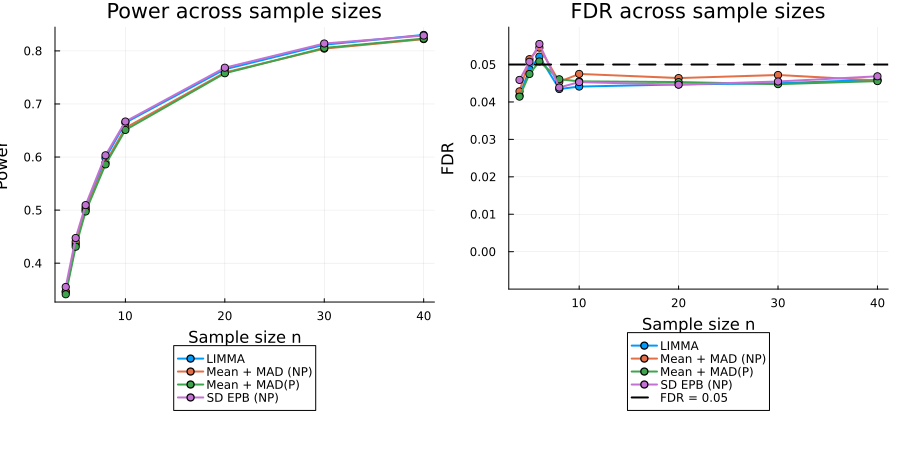

In [28]:
using Plots

# -------------------------------------------------
# 1. Build a common method dictionary
# -------------------------------------------------
method_summaries = Dict(
    "LIMMA" => limma_summary,
    "SD EPB (NP)" => epb_summary,
    "Mean + MAD (NP)" => mad_summary,
    "Mean + MAD(P)" => mad_param_gl_summary
)

# compute max FDR across all methods
max_fdr = maximum(vcat([summ["FDR"] for summ in values(method_summaries)]...))
fdr_upper = max(0.06, 1.05 * max_fdr)

# -------------------------------------------------
# 2. Power plot
# -------------------------------------------------
p_power = plot(
    xlabel = "Sample size n",
    ylabel = "Power",
    title = "Power across sample sizes",
    legend = :outerbottom,
    lw = 2,
    marker = :circle
)

for (method, summ) in method_summaries
    plot!(
        p_power,
        summ["n"],
        summ["Power"];
        label = method,
        lw = 2,
        marker = :circle
    )
end

# -------------------------------------------------
# 3. FDR plot
# -------------------------------------------------
p_fdr = plot(
    xlabel = "Sample size n",
    ylabel = "FDR",
    title = "FDR across sample sizes",
    legend = :outerbottom,
    lw = 2,
    marker = :circle,
    ylims = (-0.01, fdr_upper)
)

for (method, summ) in method_summaries
    plot!(
        p_fdr,
        summ["n"],
        summ["FDR"];
        label = method,
        lw = 2,
        marker = :circle
    )
end

hline!(
    p_fdr,
    [0.05];
    label = "FDR = 0.05",
    lw = 2,
    ls = :dash,
    color = :black
)

# -------------------------------------------------
# 4. Show side by side
# -------------------------------------------------
plot(
    p_power,
    p_fdr;
    layout = (1, 2),
    size = (900, 450)
)

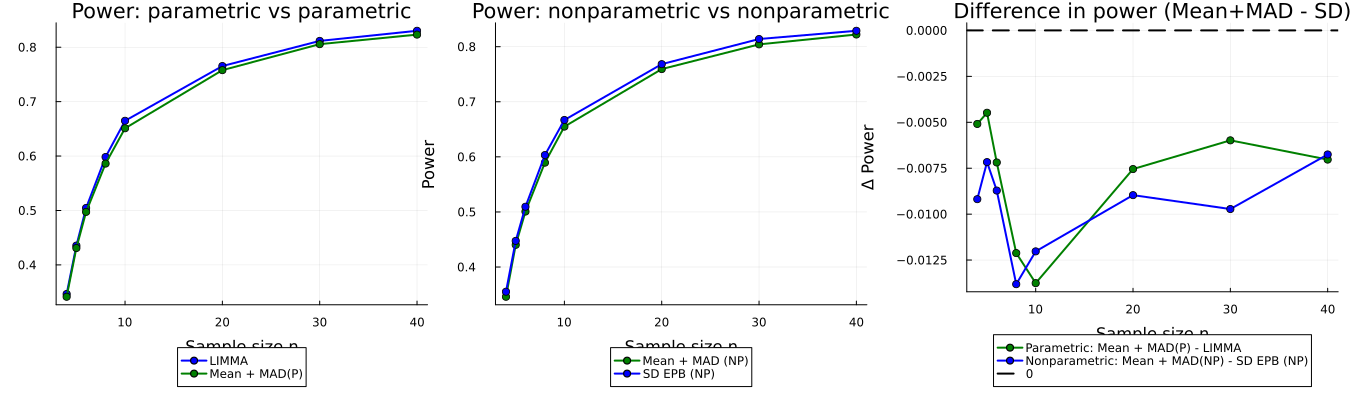

In [27]:
using Plots

# -------------------------------------------------
# 1. Split methods into two groups
# -------------------------------------------------
param_methods = Dict(
    "LIMMA" => limma_summary,
    "Mean + MAD(P)" => mad_param_gl_summary
)

nonparam_methods = Dict(
    "SD EPB (NP)" => epb_summary,
    "Mean + MAD (NP)" => mad_summary
)

# -------------------------------------------------
# 2. Shared colors
# -------------------------------------------------
method_colors = Dict(
    "LIMMA" => :blue,
    "SD EPB (NP)" => :blue,
    "Mean + MAD(P)" => :green,
    "Mean + MAD (NP)" => :green
)

# -------------------------------------------------
# 3. Power plot: parametric vs parametric
# -------------------------------------------------
p_power_param = plot(
    xlabel = "Sample size n",
    ylabel = "Power",
    title = "Power: parametric vs parametric",
    legend = :outerbottom,
    lw = 2,
    marker = :circle
)

for (method, summ) in param_methods
    plot!(
        p_power_param,
        summ["n"],
        summ["Power"];
        label = method,
        lw = 2,
        marker = :circle,
        color = method_colors[method]
    )
end

# -------------------------------------------------
# 4. Power plot: nonparametric vs nonparametric
# -------------------------------------------------
p_power_nonparam = plot(
    xlabel = "Sample size n",
    ylabel = "Power",
    title = "Power: nonparametric vs nonparametric",
    legend = :outerbottom,
    lw = 2,
    marker = :circle
)

for (method, summ) in nonparam_methods
    plot!(
        p_power_nonparam,
        summ["n"],
        summ["Power"];
        label = method,
        lw = 2,
        marker = :circle,
        color = method_colors[method]
    )
end

# -------------------------------------------------
# 5. Difference plot: Mean+MAD - SD
#    parametric: Mean+MAD(P) - LIMMA
#    nonparametric: Mean+MAD(NP) - SD EPB(NP)
# -------------------------------------------------
n_param = limma_summary["n"]
diff_param = mad_param_gl_summary["Power"] .- limma_summary["Power"]

n_nonparam = epb_summary["n"]
diff_nonparam = mad_summary["Power"] .- epb_summary["Power"]

p_diff = plot(
    xlabel = "Sample size n",
    ylabel = "Δ Power",
    title = "Difference in power (Mean+MAD - SD)",
    legend = :outerbottom,
    lw = 2,
    marker = :circle
)

plot!(
    p_diff,
    n_param,
    diff_param;
    label = "Parametric: Mean + MAD(P) - LIMMA",
    lw = 2,
    marker = :circle,
    color = :green
)

plot!(
    p_diff,
    n_nonparam,
    diff_nonparam;
    label = "Nonparametric: Mean + MAD(NP) - SD EPB (NP)",
    lw = 2,
    marker = :circle,
    color = :blue
)

hline!(
    p_diff,
    [0.0];
    label = "0",
    lw = 2,
    ls = :dash,
    color = :black
)

# -------------------------------------------------
# 6. Show all three
# -------------------------------------------------
plot(
    p_power_param,
    p_power_nonparam,
    p_diff;
    layout = (1, 3),
    size = (1350, 420)
)